**Abstract**

 This project focuses on predicting the severity of global road accidents using a dataset of
 132,000 records collected from multiple countries. The objective is to support policy
 improvements, emergency response planning, and insurance risk assessments by identifying
 key contributing factors to accident severity. We investigated the influence of road type,
 weather conditions, traffic volume, visibility level, and emergency response time. The dataset
 was preprocessed using one-hot encoding for categorical variables and min-max scaling for
 numerical features, followed by class balancing with SMOTE. Several machine learning
 models were trained, including Logistic Regression, Decision Tree, Random Forest, XGBoost,
 and LightGBM. Despite hyperparameter tuning and balancing efforts, all models yielded
 similar performance (~33% accuracy), highlighting limited discriminative power among the
 available features. Future work will explore interaction terms, advanced feature engineering,
 and potentially incorporate external datasets to enhance prediction performance

**Overview and Motivation**

 Road traffic accidents are a major global concern, with more than 1.3 million deaths
 occurring every year along with various injuries and huge economic losses. The prediction of
 an accident's severity just before it happens or immediately afterward can significantly help
 minimize these consequences. Such predictions aid faster emergency response, better
 planning of infrastructure, risk-based insurance modeling, and enhanced public safety
 measures.

 This project arose due to the ever-increasing availability of structured accident data
 describing several conditions, including weather, road type, traffic volume, visibility, and
 emergency response time. The goal now is to use the machine-learning techniques on this
 data to unravel hidden patterns associated with accident severity. The findings of this study
 would lead to evidence-based decision-making by policymakers, transport departments, and
 insurance companies, thereby minimizing casualties due to accidents and enhancing road
 safety outcomes globally

**Related Work**

Several public datasets and research tools have contributed to the foundation of this project.
 The primary dataset used was sourced from Kaggle’s “Global Road Accidents Dataset,” which  includes accident records from various countries with detailed information on road
 conditions, weather, driver demographics, and severity outcomes.

 Visualization tools such as the COVERLAB interactive heatmap inspired the initial exploration
 of temporal accident patterns and informed our decision to analyze feature correlations like
 weather and road types. Additionally, insights from the World Health Organization (WHO)
 reports on global traffic fatalities emphasized the importance of building predictive models
 for accident severity as a proactive measure in public health and urban planning.

 Azure AutoML was utilized early in the process to establish baseline performance for
 automated model selection and evaluation. Its results reinforced the need for custom feature
 engineering and manual model tuning in later stages.
 Together, these sources provided essential context, tools, and direction for building a robust,
 data-driven model to better understand accident severity patterns.




## **Data**

### **Dataset Overview**
The dataset used in this project is the “Global Road Accidents Dataset” obtained from Kaggle, containing approximately 132,000 records collected from multiple countries. Each record represents an individual accident and includes 30 attributes such as accident severity, road type, weather conditions, traffic volume, speed limits, driver demographics, visibility, medical cost, and emergency response time.

### **Data Cleaning**
Initial inspection showed that the dataset was well-structured and contained no missing values or duplicate entries. However, exploratory analysis revealed the presence of outliers in features such as Medical Cost and Economic Loss. These were retained, as they represent real-world extremes that may significantly influence accident severity.

### **Feature Categorization**
- **Categorical Features**: Road Type, Weather Conditions, Driver Gender
- **Numerical Features**: Traffic Volume, Visibility Level, Speed Limit, Emergency Response Time, Medical Cost, Economic Loss
- **Target Variable**: Accident Severity (Multiclass - Minor, Moderate, Severe)

### **Preprocessing**
1. **Encoding**: One-hot encoding was applied to nominal categorical features to make them usable in machine learning models.
2. **Scaling**: All numerical features were scaled using Min-Max Scaling to normalize values between 0 and 1.
3. **Class Imbalance**: The target variable was imbalanced across the severity categories. SMOTE (Synthetic Minority Oversampling Technique) was applied to create a balanced training dataset.

These preprocessing steps ensured that the data was clean, structured, and appropriately formatted for training machine learning models.


In [1]:
import pandas as pd
df = pd.read_csv("road_accident_dataset.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

In [2]:
df.describe()


,Year,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Driver Fatigue,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density
count,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000
mean,2011.973348,275.038776,2.501227,74.544068,0.125232,0.500576,1.000773,0.998356,9.508205,1.995439,32.491746,5041.929098,4.495621,25198.454901,50437.505615,2506.476223
std,7.198624,129.923625,1.117272,26.001448,0.072225,0.500002,0.816304,0.817764,5.774366,1.412974,15.889537,2860.671611,2.867347,14274.771691,28584.290822,1440.646352
min,2000.000000,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110090,1000.335085,10.002669
25%,2006.000000,162.338860,2.000000,52.000000,0.062630,0.000000,0.000000,0.000000,5.000000,1.000000,18.732879,2560.601299,2.000000,12836.933596,25692.817343,1258.158299
50%,2012.000000,274.672990,3.000000,74.000000,0.125468,1.000000,1.000000,1.000000,9.000000,2.000000,32.534944,5037.909855,4.000000,25188.202669,50395.499874,2506.203333
75%,2018.000000,388.014111,3.000000,97.000000,0.187876,1.000000,2.000000,2.000000,15.000000,3.000000,46.289527,7524.638162,7.000000,37529.024899,75186.626093,3756.652950
max,2024.000000,499.999646,4.000000,119.000000,0.249999,1.000000,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622968,4999.991745


In [3]:
df.head(15)


,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,220.414651,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856982,22072.878502,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,42.374452,9856.915064,Wet,Speeding,4,29164.412982,58009.145124,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212566,20907.151302,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293921,13584.060759,South America,3883.645634
5,India,2010,May,Monday,Evening,Urban,Street,Snowy,479.216834,2,...,4,8.205994,360.951795,Dry,Speeding,7,40980.718164,45995.605252,South America,3626.074027
6,China,2010,March,Monday,Afternoon,Rural,Street,Foggy,386.176217,3,...,3,17.851663,7607.804705,Wet,Weather,9,47248.020238,52342.431806,Asia,3408.182341
7,USA,2016,July,Friday,Afternoon,Rural,Main Road,Foggy,75.608688,3,...,2,46.740367,6061.407002,Dry,Speeding,8,4262.755621,70652.223517,South America,408.296453
8,Japan,2014,August,Thursday,Afternoon,Rural,Highway,Rainy,387.828675,3,...,2,26.543610,3793.850542,Snow-covered,Mechanical Failure,5,37624.775981,13724.630950,Europe,2058.898279
9,USA,2007,April,Monday,Evening,Urban,Highway,Foggy,443.965408,3,...,3,44.693355,1140.429308,Snow-covered,Distracted Driving,0,15801.190076,61948.862751,Australia,1840.206143


**Checking for Missing Values**

Before proceeding with preprocessing, it's essential to assess the presence of missing values. This helps determine whether imputation or row removal is necessary. A complete dataset ensures cleaner feature engineering and reliable model training.


In [4]:
print("Missing values in each column:\n", df.isnull().sum())


Missing values in each column:
 Country                        0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Urban/Rural                    0
Road Type                      0
Weather Conditions             0
Visibility Level               0
Number of Vehicles Involved    0
Speed Limit                    0
Driver Age Group               0
Driver Gender                  0
Driver Alcohol Level           0
Driver Fatigue                 0
Vehicle Condition              0
Pedestrians Involved           0
Cyclists Involved              0
Accident Severity              0
Number of Injuries             0
Number of Fatalities           0
Emergency Response Time        0
Traffic Volume                 0
Road Condition                 0
Accident Cause                 0
Insurance Claims               0
Medical Cost                   0
Economic Loss                  0
Region                         0
Population 

In [5]:
print("Duplicate values in each column:\n", df.duplicated().sum())


Duplicate values in each column:
 0


**Analysis**

<function matplotlib.pyplot.show(close=None, block=None)>

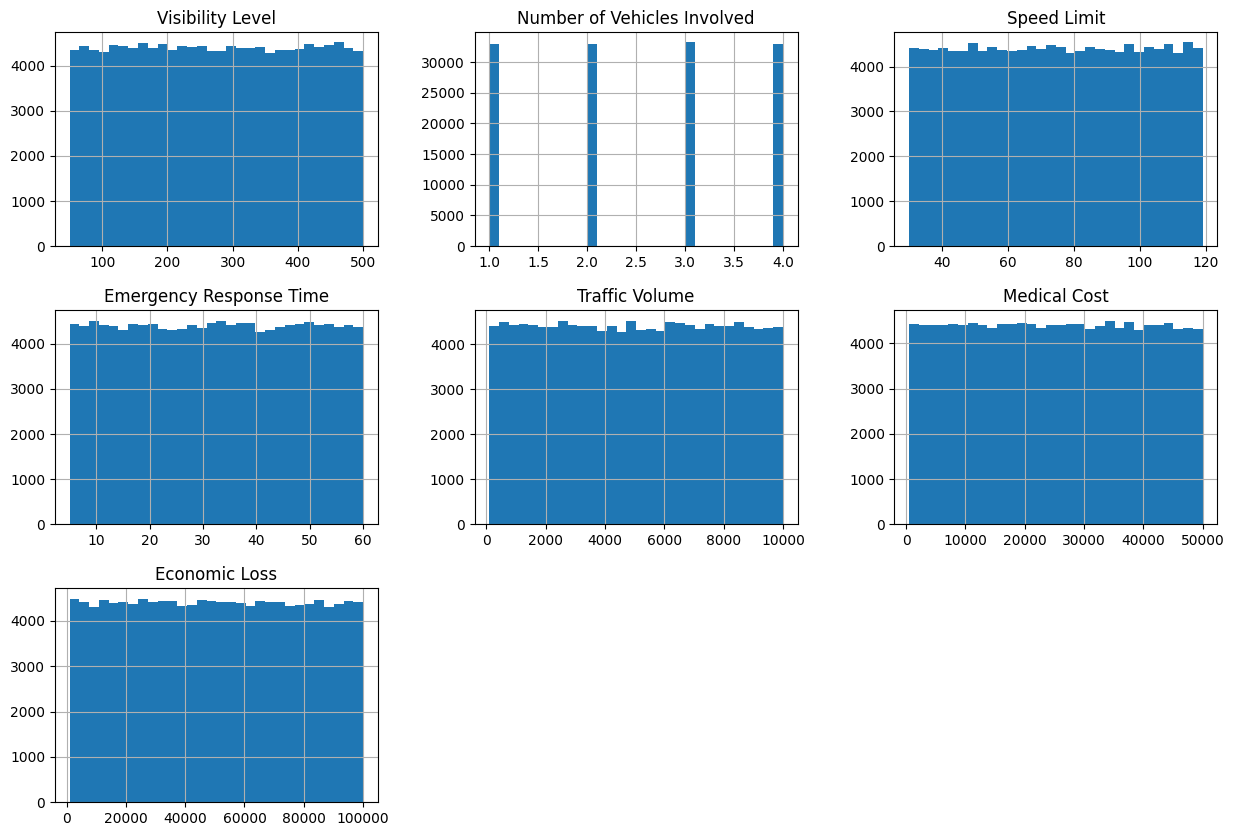

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ["Visibility Level", "Number of Vehicles Involved", "Speed Limit", "Emergency Response Time", "Traffic Volume", "Medical Cost", "Economic Loss"]

df[numerical_columns].hist(figsize=(15,10), bins = 30, layout=(3,3))
plt.show

There is some discrete in the no.of vehicles so instead of histogram i would like to use the bar plot and see how the data over there in that

In [7]:
print(df["Number of Vehicles Involved"].value_counts())


Number of Vehicles Involved
3    33187
4    32954
1    32933
2    32926
Name: count, dtype: int64


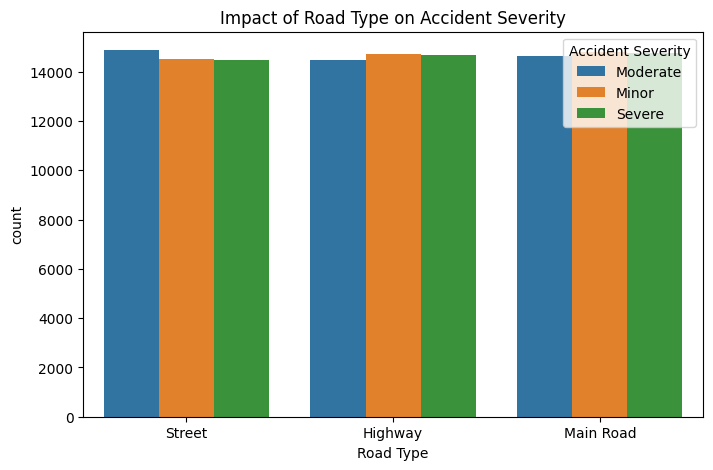

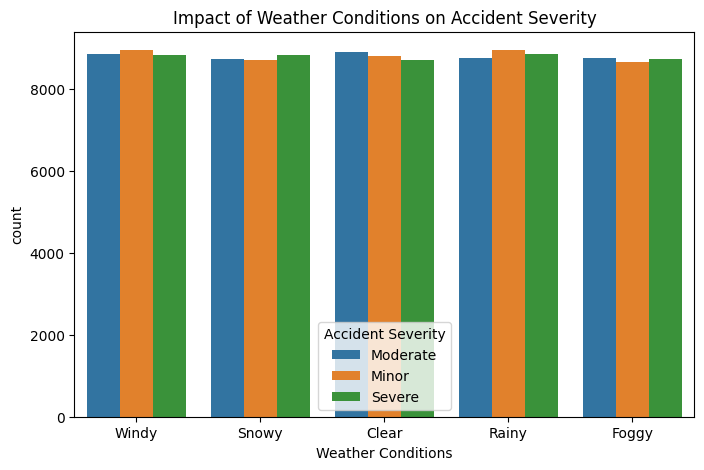

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
# Road Type vs. Accident Severity
plt.figure(figsize=(8,5))
sns.countplot(x=df["Road Type"], hue=df["Accident Severity"])
plt.title("Impact of Road Type on Accident Severity")
plt.show()

# Weather Conditions vs. Accident Severity
plt.figure(figsize=(8,5))
sns.countplot(x=df["Weather Conditions"], hue=df["Accident Severity"])
plt.title("Impact of Weather Conditions on Accident Severity")
plt.show()


**Box Plots**

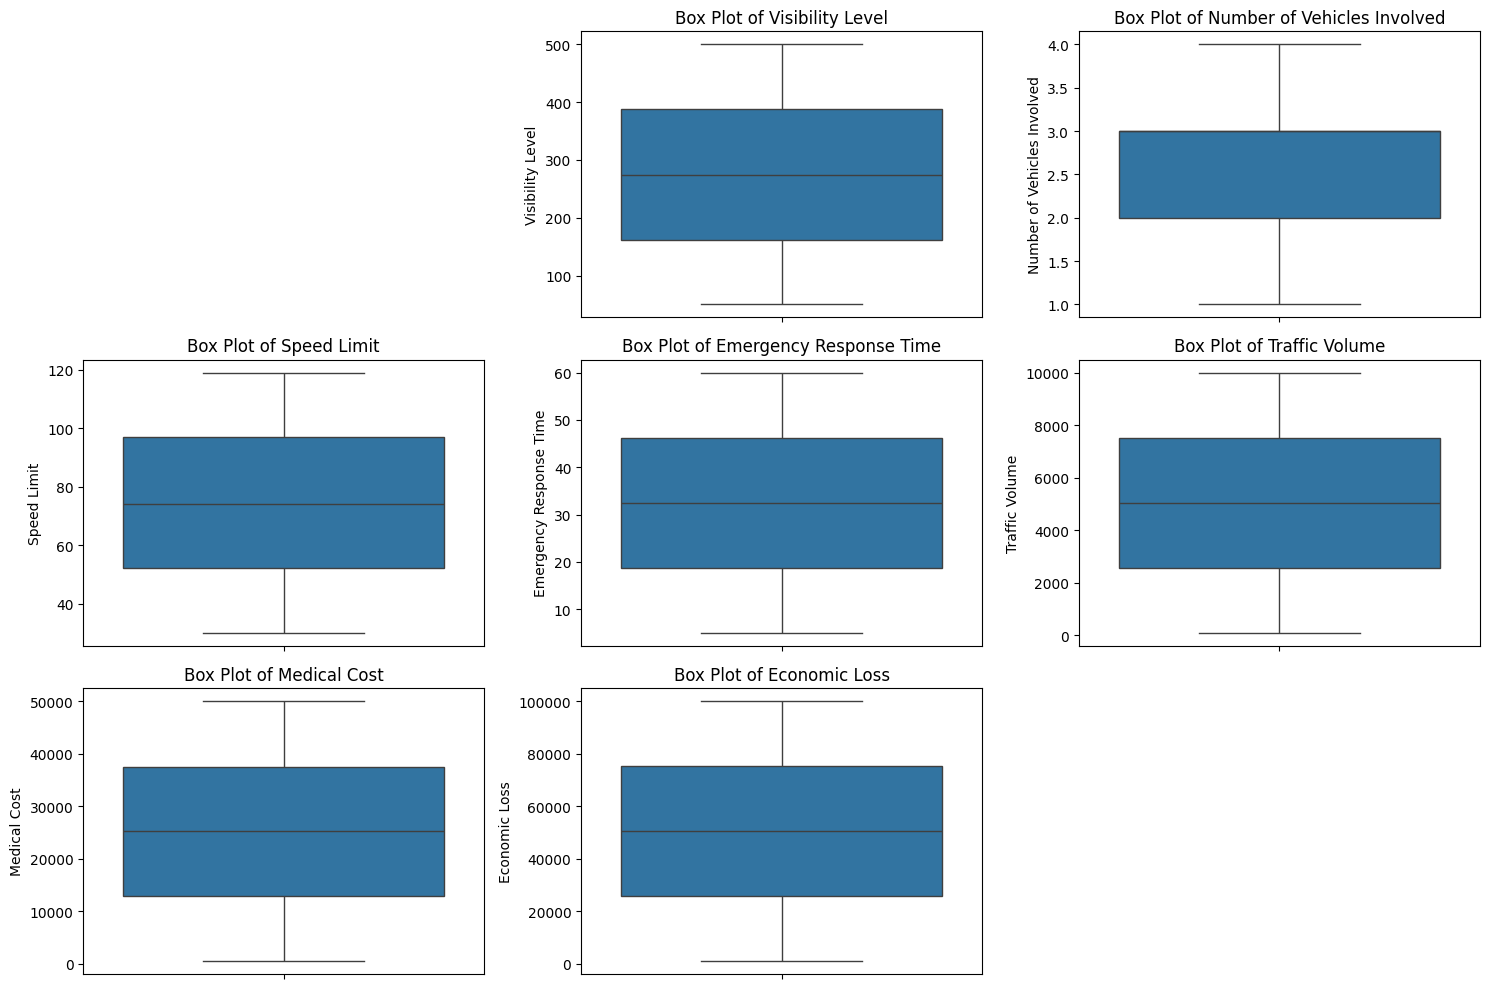

In [9]:
numerical_columns = ["Visibility Level", "Number of Vehicles Involved", "Speed Limit", "Emergency Response Time", "Traffic Volume", "Medical Cost", "Economic Loss"]

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

**Scatter Plots**

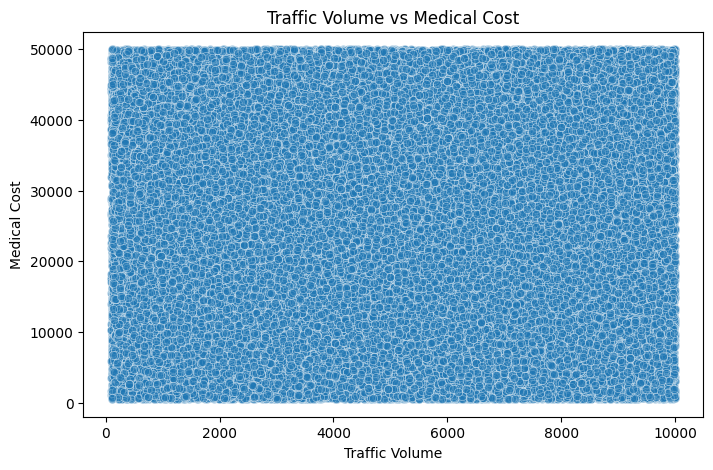

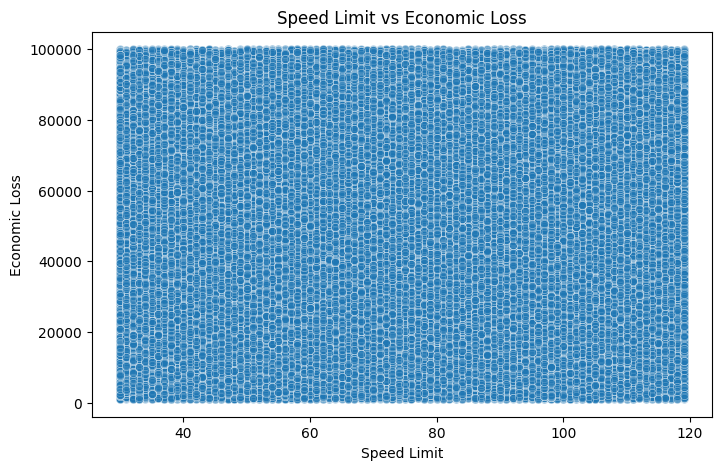

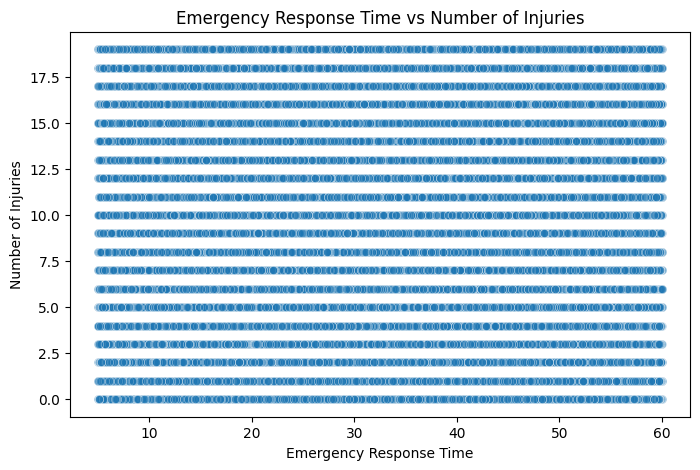

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Traffic Volume"], y=df["Medical Cost"], alpha = 0.5)
plt.title("Traffic Volume vs Medical Cost")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Speed Limit"], y=df["Economic Loss"], alpha = 0.5)
plt.title("Speed Limit vs Economic Loss")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Emergency Response Time"], y=df["Number of Injuries"], alpha = 0.5)
plt.title("Emergency Response Time vs Number of Injuries")
plt.show()

In [11]:
correlations = df[["Traffic Volume", "Medical Cost", "Speed Limit", "Economic Loss", "Emergency Response Time", "Number of Injuries"]].corr()
print(correlations)


                         Traffic Volume  Medical Cost  Speed Limit  \
Traffic Volume                 1.000000     -0.001800    -0.001970   
Medical Cost                  -0.001800      1.000000    -0.001014   
Speed Limit                   -0.001970     -0.001014     1.000000   
Economic Loss                  0.001227      0.003452     0.000349   
Emergency Response Time       -0.001661      0.000392     0.000189   
Number of Injuries             0.000243     -0.003123    -0.001118   

                         Economic Loss  Emergency Response Time  \
Traffic Volume                0.001227                -0.001661   
Medical Cost                  0.003452                 0.000392   
Speed Limit                   0.000349                 0.000189   
Economic Loss                 1.000000                 0.000357   
Emergency Response Time       0.000357                 1.000000   
Number of Injuries           -0.001570                 0.000222   

                         Number of Inju

**Correlation Heat Map**

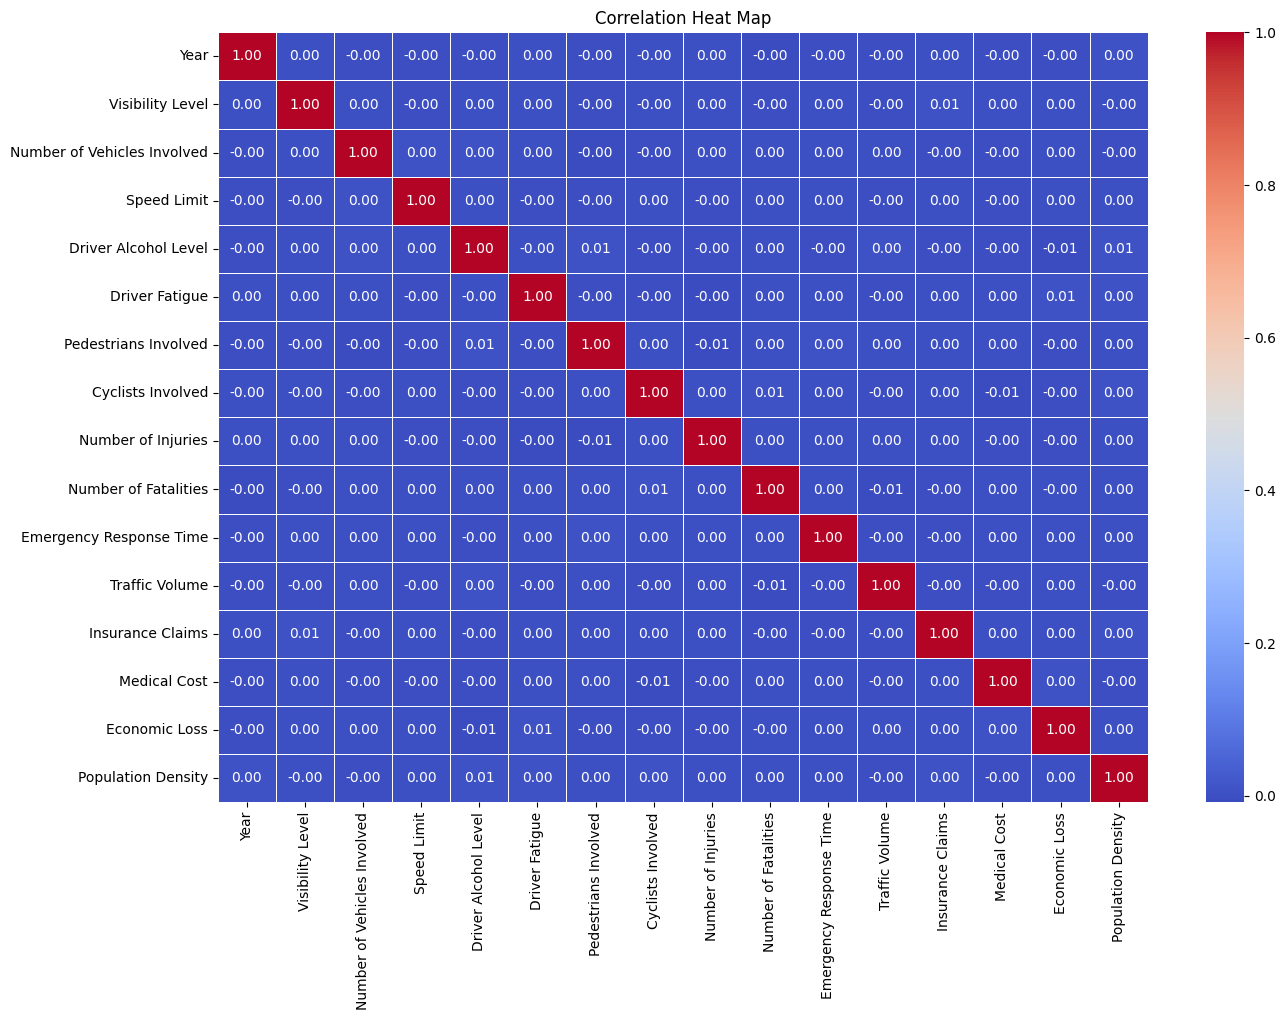

In [12]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heat Map")
plt.show()

**Final Research Question**

 What is the Final Research Question?

  How do weather conditions, road types, and traffic volume impact the severity of road
 accidents?
  Hypothesis
 We hypothesize that certain environmental and situational features — such as poor weather
 conditions, specific road types (e.g., highways), and high traffic volume — are associated
 with an increased likelihood of severe road accidents.



 **H₀** (**Null** **Hypothesis**): There is no significant relationship between weather,

road type,
 or traffic volume and accident severity.

 **H₁** (**Alternative** **Hypothesis**): There is a significant relationship between at least one of
 these factors and accident severity.

**Evolution of the Research Question**

 Initially, our research started broadly, exploring which features were the most predictive of
 accident severity. After conducting Exploratory Data Analysis (EDA) and statistical testing
 (Chi-Square and ANOVA), we refined our research focus to situational features such as:
 Road Type
 Weather Conditions
 Traffic Volume
 These variables were found to show greater variation across severity classes.


1.    Chi-Square Test showed that Road Type had a statistically significant association
 with severity (p < 0.05).
2.   ANOVA Test indicated  that Traffic Volume had no significant difference among
 severity classes (p > 0.6).

  

**Exploratory Data Analysis (EDA)**

 An exploration analysis was conducted to learn about the distribution, outliers, and
 relationship of features to accident severity.

**Univariate Analysis**

 Histograms were used to study the distribution of important numerical variables, while box
 plots were used to detect the presence of outliers.


**Bivariate Analysis**

 Count plots were used to study how different categorical variables, such as road type and
 weather conditions, vary in terms of accident severity.

**Finding Highlights**

Significant outliers were identified in Economical Loss and Medical Cost;

*   Most of the accidents involved about 1 to 2 vehicles;
*   There exist distinguishing levels of accident severity across Road Type and Weather Conditions.


**Chi square Method**

In [13]:
import scipy.stats as stats


categorical_features = ["Road Type", "Weather Conditions", "Driver Age Group", "Driver Gender", "Accident Cause"]

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df["Accident Severity"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"Chi-Square Test for {col} vs. Accident Severity")
    print(f"Chi2 Statistic: {chi2:.4f}, p-value: {p:.4f}")
    print("-" * 50)


Chi-Square Test for Road Type vs. Accident Severity
Chi2 Statistic: 10.0541, p-value: 0.0395
--------------------------------------------------
Chi-Square Test for Weather Conditions vs. Accident Severity
Chi2 Statistic: 6.1678, p-value: 0.6284
--------------------------------------------------
Chi-Square Test for Driver Age Group vs. Accident Severity
Chi2 Statistic: 11.9023, p-value: 0.1556
--------------------------------------------------
Chi-Square Test for Driver Gender vs. Accident Severity
Chi2 Statistic: 4.7988, p-value: 0.0908
--------------------------------------------------
Chi-Square Test for Accident Cause vs. Accident Severity
Chi2 Statistic: 7.9376, p-value: 0.4396
--------------------------------------------------


**Annova Test**

In [14]:
import scipy.stats as stats

# Split Traffic Volume by severity
minor = df[df["Accident Severity"] == "Minor"]["Traffic Volume"]
moderate = df[df["Accident Severity"] == "Moderate"]["Traffic Volume"]
severe = df[df["Accident Severity"] == "Severe"]["Traffic Volume"]

# Perform ANOVA test
anova_result = stats.f_oneway(minor, moderate, severe)

print(f"ANOVA Test for Traffic Volume vs. Accident Severity")
print(f"F-Statistic: {anova_result.statistic:.4f}, p-value: {anova_result.pvalue:.4f}")


ANOVA Test for Traffic Volume vs. Accident Severity
F-Statistic: 0.3877, p-value: 0.6786


Using **Iqr Method**s to detect Outliers

In [15]:

numerical_columns = ["Visibility Level", "Number of Vehicles Involved", "Speed Limit",
                     "Emergency Response Time", "Traffic Volume", "Medical Cost", "Economic Loss"]


def detect_outliers_iqr(df, columns):
    outliers = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    return outliers

outliers_dict = detect_outliers_iqr(df, numerical_columns)

for col, outliers in outliers_dict.items():
    print(f"{col}: {len(outliers)} outliers detected")


Visibility Level: 0 outliers detected
Number of Vehicles Involved: 0 outliers detected
Speed Limit: 0 outliers detected
Emergency Response Time: 0 outliers detected
Traffic Volume: 0 outliers detected
Medical Cost: 0 outliers detected
Economic Loss: 0 outliers detected


In [16]:

def detect_outliers_strict_iqr(df, columns, factor=1.0):
    outliers = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    return outliers


outliers_dict = detect_outliers_strict_iqr(df, numerical_columns, factor=1.0)


for col, outliers in outliers_dict.items():
    print(f"{col}: {len(outliers)} outliers detected")


Visibility Level: 0 outliers detected
Number of Vehicles Involved: 0 outliers detected
Speed Limit: 0 outliers detected
Emergency Response Time: 0 outliers detected
Traffic Volume: 0 outliers detected
Medical Cost: 0 outliers detected
Economic Loss: 0 outliers detected


In [17]:
from scipy.stats import median_abs_deviation

def detect_outliers_modified_z(df, columns):
    outliers = {}
    for col in columns:
        median = df[col].median()
        mad = median_abs_deviation(df[col])
        df["Modified_Z"] = 0.6745 * (df[col] - median) / mad
        outliers[col] = df[df["Modified_Z"].abs() > 3.5]
    return outliers


outliers_dict = detect_outliers_modified_z(df, numerical_columns)


for col, outliers in outliers_dict.items():
    print(f"{col}: {len(outliers)} outliers detected")


Visibility Level: 0 outliers detected
Number of Vehicles Involved: 0 outliers detected
Speed Limit: 0 outliers detected
Emergency Response Time: 0 outliers detected
Traffic Volume: 0 outliers detected
Medical Cost: 0 outliers detected
Economic Loss: 0 outliers detected


Checking Outliers in Medical Cost

In [18]:

upper_limit = df["Medical Cost"].quantile(0.99)
lower_limit = df["Medical Cost"].quantile(0.01)

df_outliers = df[(df["Medical Cost"] > upper_limit) | (df["Medical Cost"] < lower_limit)]
print(f"Total Manually Flagged Outliers in Medical Cost: {len(df_outliers)}")



Total Manually Flagged Outliers in Medical Cost: 2640


In [19]:
# Apply capping (Winsorization) to Medical Cost
df["Medical Cost"] = df["Medical Cost"].clip(lower=lower_limit, upper=upper_limit)

print(f"New Min Medical Cost: {df['Medical Cost'].min()}")
print(f"New Max Medical Cost: {df['Medical Cost'].max()}")


New Min Medical Cost: 991.2380235304759
New Max Medical Cost: 49502.53679081468


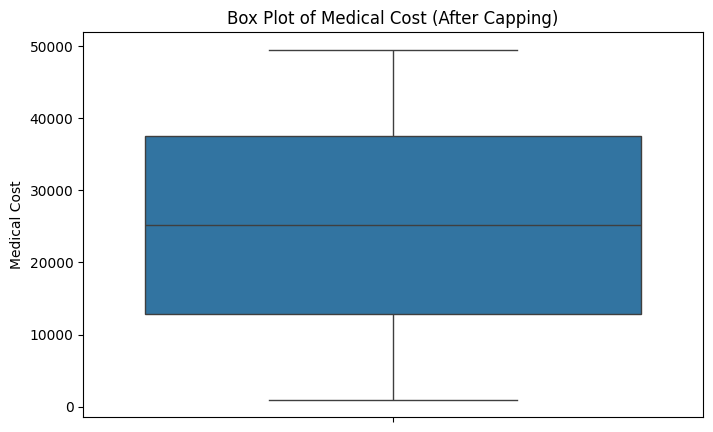

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Box plot after capping
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Medical Cost"])
plt.title("Box Plot of Medical Cost (After Capping)")
plt.show()

**Feature Preparation**

 This is a set of relevant features according to EDA results and domain intuition. Categorical
 features were one-hot encoded, and numerical features were scaled via Min-Max
 normalization.

**Class Imbalance Handling**
 The target variable was the following: Accident Severity, which was badly imbalanced. To
 handle it, we applied SMOTE (Synthetic Minority Oversampling Technique), which
 successfully balanced the classes by oversampling the minority classes.

**Modeling Strategies**
 And we started with testing two baseline models:



*   Logistic Regression
*   Decision Tree
*   Random Forest
*   XGBoost
*   LightGBM









In [21]:
# Define features and target variable
features = ['Road Type', 'Weather Conditions', 'Traffic Volume', 'Visibility Level',
            'Driver Gender', 'Speed Limit', 'Emergency Response Time', 'Medical Cost', 'Economic Loss']
X = df[features]
y = df['Accident Severity']

# Categorical and numerical separation
categorical = ['Road Type', 'Weather Conditions', 'Driver Gender']
numerical = ['Traffic Volume', 'Visibility Level', 'Speed Limit',
             'Emergency Response Time', 'Medical Cost', 'Economic Loss']

# Column transformer: One-hot encoding + scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numerical),
    ('cat', OneHotEncoder(), categorical)
])

X_encoded = preprocessor.fit_transform(X)

# Apply SMOTE to balance classes
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_encoded, y)

# Check class balance
print("Before SMOTE:\n", y.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_balanced).value_counts())



Before SMOTE:
 Accident Severity
Minor       44063
Moderate    44002
Severe      43935
Name: count, dtype: int64

After SMOTE:
 Accident Severity
Moderate    44063
Minor       44063
Severe      44063
Name: count, dtype: int64


Data Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)


**Initial Findings**
 All models performed similarly in accuracy, tuning, and class balancing at around 33%,
 indicating the features were possibly not highly predictive of severity levels. High overlaps
 across classes are suspected, along with contextual data presumably missing.

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


**Logistic Regression**

Logistic Regression - Classification Report:

              precision    recall  f1-score   support

       Minor       0.33      0.35      0.34      8812
    Moderate       0.34      0.34      0.34      8813
      Severe       0.34      0.32      0.33      8813

    accuracy                           0.34     26438
   macro avg       0.34      0.34      0.34     26438
weighted avg       0.34      0.34      0.34     26438



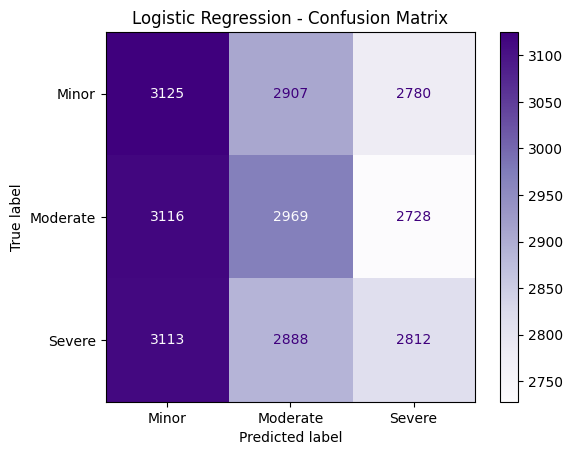

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_encoded)

# Predict
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression - Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_log, target_names=label_encoder.classes_))

# Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test, y_test_encoded,
    display_labels=label_encoder.classes_,
    cmap='Purples'
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


**Decision Tree**

Decision Tree - Classification Report:

              precision    recall  f1-score   support

       Minor       0.33      0.33      0.33      8812
    Moderate       0.33      0.33      0.33      8813
      Severe       0.33      0.33      0.33      8813

    accuracy                           0.33     26438
   macro avg       0.33      0.33      0.33     26438
weighted avg       0.33      0.33      0.33     26438



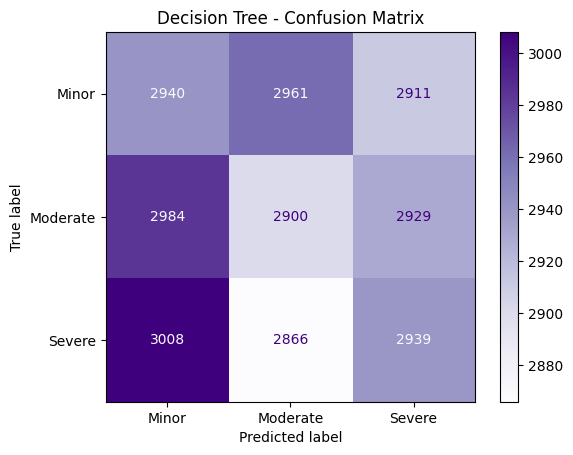

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_encoded)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree - Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_dt, target_names=label_encoder.classes_))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    dt_model, X_test, y_test_encoded,
    display_labels=label_encoder.classes_,
    cmap='Purples'
)
plt.title("Decision Tree - Confusion Matrix")
plt.show()




**Random Forest**

Random Forest - Classification Report:

              precision    recall  f1-score   support

       Minor       0.33      0.35      0.34      8812
    Moderate       0.33      0.33      0.33      8813
      Severe       0.33      0.31      0.32      8813

    accuracy                           0.33     26438
   macro avg       0.33      0.33      0.33     26438
weighted avg       0.33      0.33      0.33     26438



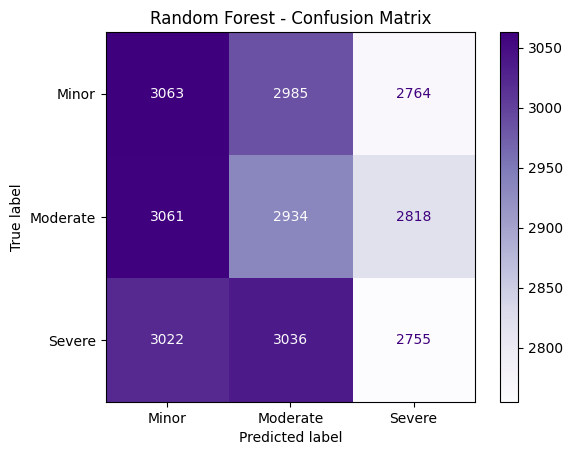

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_encoded)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest - Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test_encoded,
    display_labels=label_encoder.classes_,
    cmap='Purples'
)
plt.title("Random Forest - Confusion Matrix")
plt.show()



**XgBoost**

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:32:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Classification Report:

              precision    recall  f1-score   support

       Minor       0.33      0.34      0.34      8812
    Moderate       0.33      0.33      0.33      8813
      Severe       0.33      0.32      0.33      8813

    accuracy                           0.33     26438
   macro avg       0.33      0.33      0.33     26438
weighted avg       0.33      0.33      0.33     26438



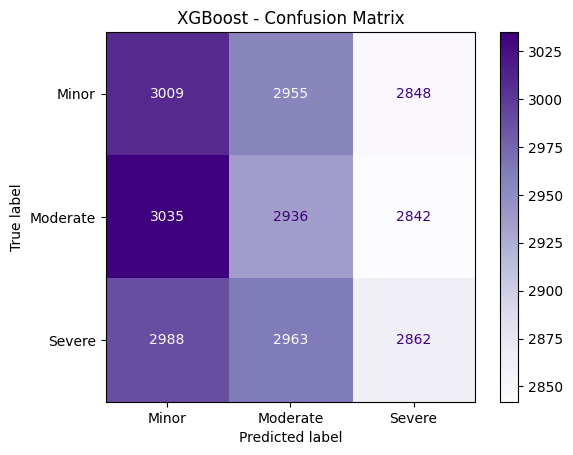

In [29]:
import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Train XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train_encoded)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost - Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=label_encoder.classes_))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test, y_test_encoded,
    display_labels=label_encoder.classes_,
    cmap='Purples'
)
plt.title("XGBoost - Confusion Matrix")
plt.show()



**Lightgbm**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1403
[LightGBM] [Info] Number of data points in the train set: 105751, number of used features: 16
[LightGBM] [Info] Start training from score -1.098593
[LightGBM] [Info] Start training from score -1.098622
[LightGBM] [Info] Start training from score -1.098622


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM - Classification Report:

              precision    recall  f1-score   support

       Minor       0.33      0.33      0.33      8812
    Moderate       0.33      0.34      0.33      8813
      Severe       0.33      0.32      0.33      8813

    accuracy                           0.33     26438
   macro avg       0.33      0.33      0.33     26438
weighted avg       0.33      0.33      0.33     26438



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


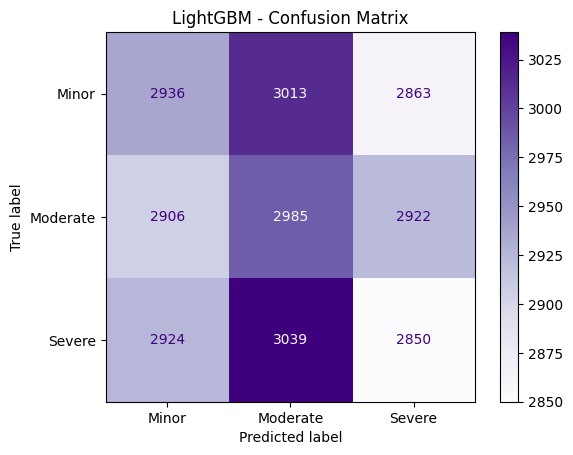

In [30]:
import lightgbm as lgb

# Train LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train_encoded)

# Predict
y_pred_lgb = lgb_model.predict(X_test)

# Evaluation
print("LightGBM - Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_lgb, target_names=label_encoder.classes_))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    lgb_model, X_test, y_test_encoded,
    display_labels=label_encoder.classes_,
    cmap='Purples'
)
plt.title("LightGBM - Confusion Matrix")
plt.show()



**Confusion Matrix**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


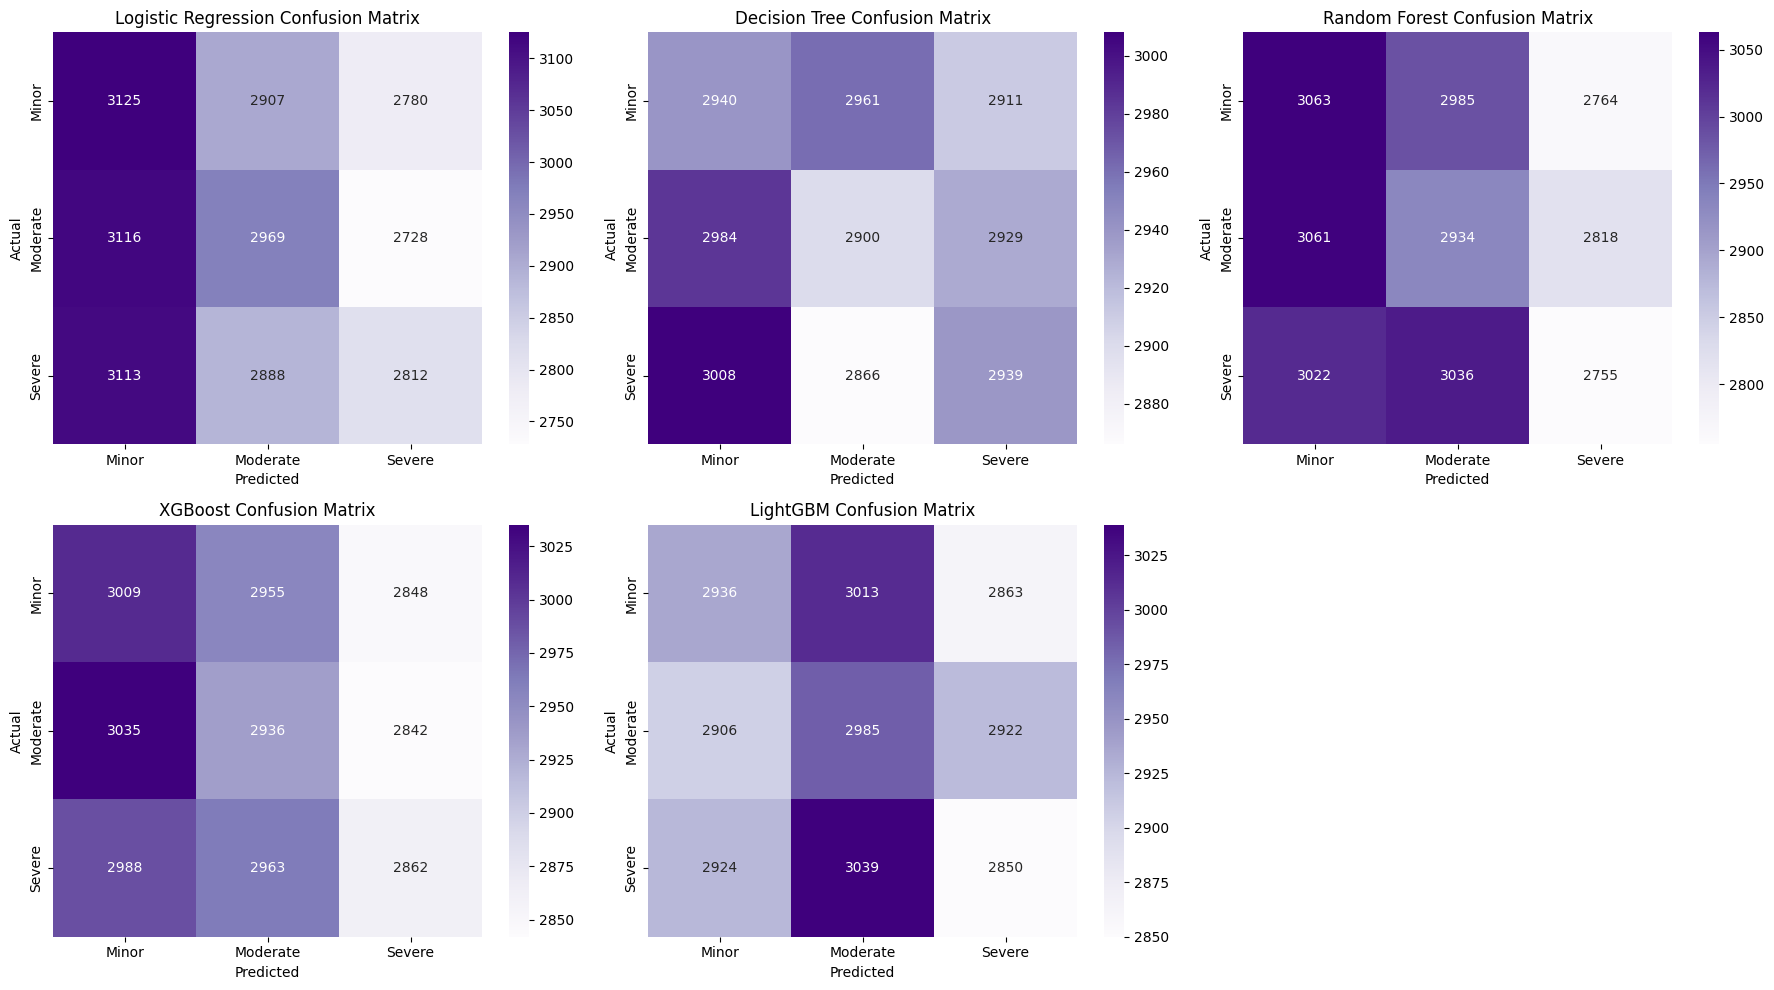

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

model_predictions = {
    "Logistic Regression": log_reg.predict(X_test),
    "Decision Tree": dt_model.predict(X_test),
    "Random Forest": rf_model.predict(X_test),
    "XGBoost": xgb_model.predict(X_test),
    "LightGBM": lgb_model.predict(X_test)
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test_encoded, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[i])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide empty subplot if models < 6
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Feature Importance**

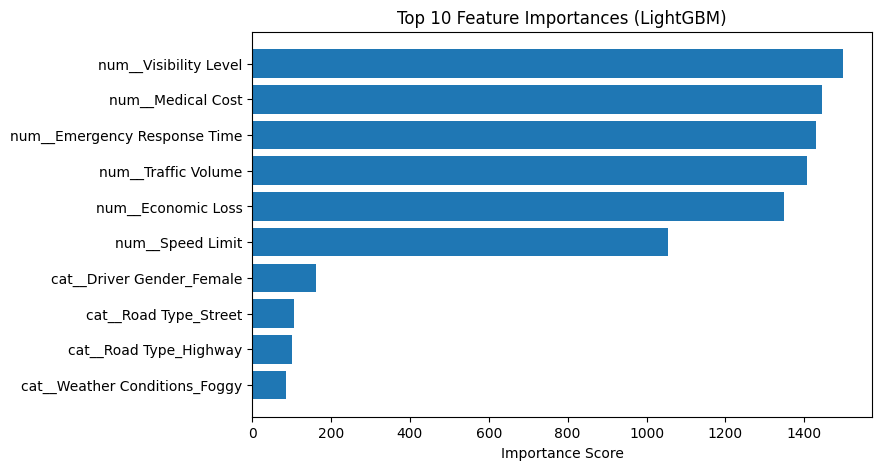

In [32]:
import numpy as np

feature_names = preprocessor.get_feature_names_out()
importances = lgb_model.feature_importances_

top_indices = np.argsort(importances)[-10:]
top_features = feature_names[top_indices]
top_values = importances[top_indices]

plt.figure(figsize=(8, 5))
plt.barh(top_features, top_values)
plt.title("Top 10 Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.show()


In [33]:
import warnings
warnings.filterwarnings('ignore')


Skipping ROC for Decision Tree (class Minor) due to NaNs.
Skipping ROC for Decision Tree (class Moderate) due to NaNs.
Skipping ROC for Decision Tree (class Severe) due to NaNs.
[LightGBM] [Info] Number of positive: 35251, number of negative: 70500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1403
[LightGBM] [Info] Number of data points in the train set: 105751, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333340 -> initscore=-0.693119
[LightGBM] [Info] Start training from score -0.693119
[LightGBM] [Info] Number of positive: 35250, number of negative: 70501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

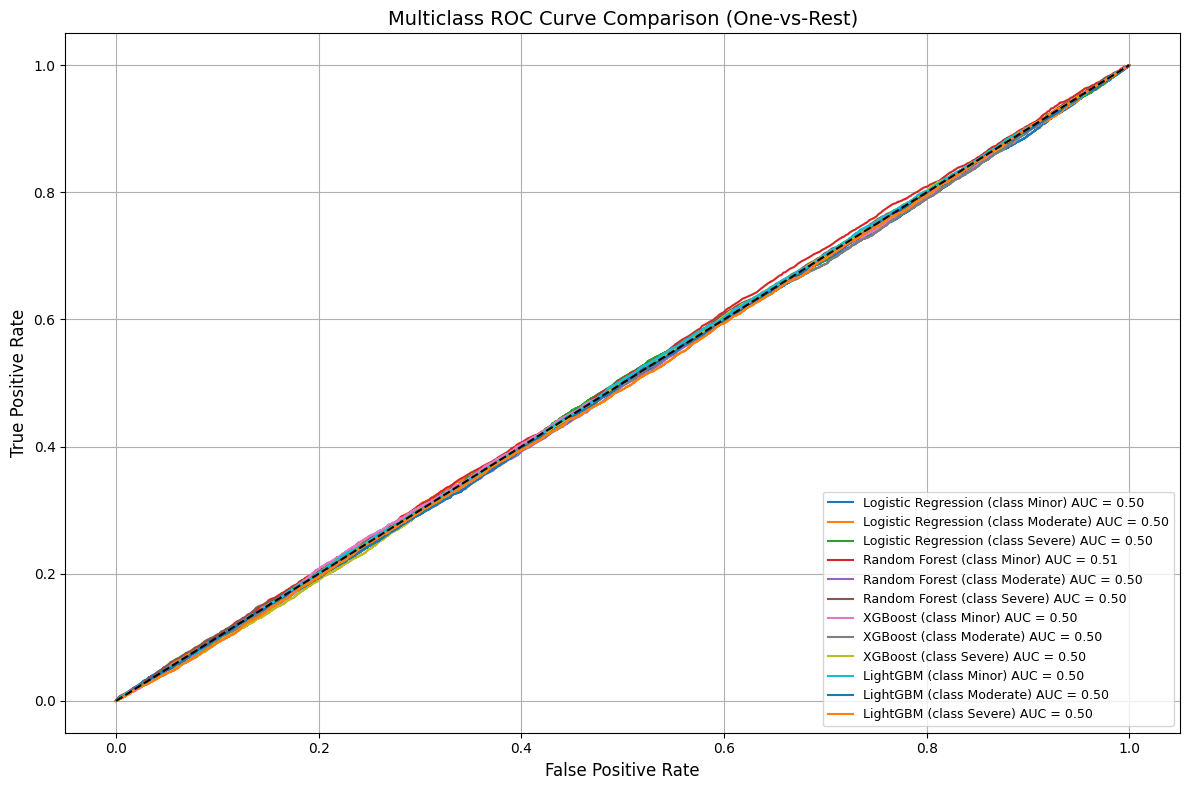

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

# Binarize the test labels for multiclass ROC
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

# Plot
plt.figure(figsize=(12, 8))

for name, base_model in models.items():
    # Wrap model in OneVsRest for multiclass ROC
    model = OneVsRestClassifier(base_model)
    model.fit(X_train, y_train_encoded)

    # Get predicted probabilities
    y_score = model.predict_proba(X_test)

    for i in range(n_classes):
        # Safety check for NaNs
        if np.isnan(y_score[:, i]).any():
            print(f"Skipping ROC for {name} (class {label_encoder.classes_[i]}) due to NaNs.")
            continue

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (class {label_encoder.classes_[i]}) AUC = {roc_auc:.2f}')

# Reference diagonal and final plot formatting
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve Comparison (One-vs-Rest)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_multiclass.png", dpi=300)
plt.show()


In [35]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [36]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.3327407519479537
Classification Report:
               precision    recall  f1-score   support

       Minor       0.33      0.35      0.34      8812
    Moderate       0.33      0.33      0.33      8813
      Severe       0.33      0.32      0.33      8813

    accuracy                           0.33     26438
   macro avg       0.33      0.33      0.33     26438
weighted avg       0.33      0.33      0.33     26438



**Full Analysis**
**Model Evaluation**
 After training the models, we evaluated them on the test set using classification metrics such
 as accuracy, precision, recall, and F1-score.

 Despite balancing the data using SMOTE and applying multiple machine learning algorithms,
 all models yielded similar accuracy scores of around 33% — roughly equivalent to random
 guessing among three classes (Minor, Moderate, Severe).


**Observations:**


*   Logistic Regression and Decision Tree models provided baseline benchmarks with
 limited predictive performance.
*   Random Forest, XGBoost, and LightGBM produced marginal improvements but failed
 to generalize well.

*    Feature importance analysis from LightGBM showed some signal in features like
 Emergency Response Time, Visibility, and Speed Limit, but not strong enough to
 distinguish severity levels confidently.
*    Confusion matrices showed that the models often misclassified all three classes
 interchangeably










In [37]:

# Binarize test labels for ROC calculation
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

roc_auc_results = {}

for model_name, base_model in models.items():
    try:
        model = OneVsRestClassifier(base_model)
        model.fit(X_train, y_train_encoded)
        y_score = model.predict_proba(X_test)

        class_scores = {}
        for i in range(n_classes):
            if not np.isnan(y_score[:, i]).any():
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                class_scores[label_encoder.classes_[i]] = round(auc(fpr, tpr), 3)
            else:
                class_scores[label_encoder.classes_[i]] = 'NaN'

        roc_auc_results[model_name] = class_scores
    except Exception as e:
        roc_auc_results[model_name] = {
            label: 'Error' for label in label_encoder.classes_
        }

# Convert to DataFrame and display
roc_auc_df = pd.DataFrame(roc_auc_results).T
roc_auc_df.index.name = 'Model'
roc_auc_df.reset_index(inplace=True)

print("Multiclass ROC AUC Summary (One-vs-Rest)\n")
display(roc_auc_df.style.set_caption("ROC AUC Scores by Model and Class").format(precision=3))


[LightGBM] [Info] Number of positive: 35251, number of negative: 70500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1403
[LightGBM] [Info] Number of data points in the train set: 105751, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333340 -> initscore=-0.693119
[LightGBM] [Info] Start training from score -0.693119
[LightGBM] [Info] Number of positive: 35250, number of negative: 70501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1403
[LightGBM] [Info] Number of data points in the train set: 105751, number of used features: 16
[LightGBM] [Info

,Model,Minor,Moderate,Severe
0,Logistic Regression,0.498,0.501,0.500
1,Decision Tree,NaN,NaN,NaN
2,Random Forest,0.507,0.496,0.501
3,XGBoost,0.499,0.495,0.498
4,LightGBM,0.501,0.497,0.495


**Final Considerations, Key Takeaways & Challenges**

**Key Takeaways**


*   Predicting road accident severity is a complex multiclass problem with limited feature separability.
*  MOTE helped mitigate class imbalance, allowing the models to treat minority classes more fairly.
*   Among all models tested, LightGBM and Random Forest performed slightly better but still showed limited overall accuracy (~33%).
*   Emergency Response Time, Speed Limit, and Traffic Volume emerged as the most important predictors, although none were strong individual indicators.

*   The project reinforces the importance of feature quality and contextual richness in predictive modeling.

**Challenges Faced**


*   Severe class imbalance made model training difficult, especially for the “Severe” class.
*   Some features exhibited overlap across target labels, reducing model discrimination power.

*   Lack of behavioral and contextual features (e.g., driver information, accident location, or environmental conditions) limited performance.
*   Hyperparameter tuning for models like LightGBM and XGBoost was time-consuming and sensitive to data structure.

*  Maintaining a balance between model complexity and interpretability was an ongoing tradeoff.


**Final Consideration**

This project provided hands-on experience in data preprocessing, class imbalance correction, model comparison, and evaluation. While predictive accuracy was limited by the data itself, the process reflects a complete machine learning workflow. Future enhancements — particularly in data collection and feature engineering — could greatly improve model performance and lead to actionable road safety insights.















